In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#loading the dataset
bitcoin = pd.read_csv("/content/coin_Bitcoin_with_errors.csv")

In [9]:
print("Number of rows:", bitcoin.shape[0])
print("Number of columns:", bitcoin.shape[1])
print("Dataset shape:", bitcoin.shape)

Number of rows: 2996
Number of columns: 10
Dataset shape: (2996, 10)


In [7]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2996 entries, 0 to 2995
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2996 non-null   int64  
 1   Name       2996 non-null   object 
 2   Symbol     2996 non-null   object 
 3   Date       2995 non-null   object 
 4   High       2995 non-null   object 
 5   Low        2995 non-null   object 
 6   Open       2995 non-null   float64
 7   Close      2995 non-null   object 
 8   Volume     2995 non-null   float64
 9   Marketcap  2995 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 234.2+ KB


In [8]:
print("Missing values in each column:")
print(bitcoin.isnull().sum())

Missing values in each column:
SNo          0
Name         0
Symbol       0
Date         1
High         1
Low          1
Open         1
Close        1
Volume       1
Marketcap    1
dtype: int64


data cleaning


In [12]:
bitcoin_original = bitcoin.copy()

In [13]:
print("Missing values:")
print(bitcoin.isnull().sum())

print("\nDuplicate rows:", bitcoin.duplicated().sum())

print("\nData types:")
print(bitcoin.dtypes)

print("\nUnique Name values:")
print(bitcoin["Name"].unique())

print("\nUnique Symbol values:")
print(bitcoin["Symbol"].unique())

Missing values:
SNo          0
Name         0
Symbol       0
Date         1
High         1
Low          1
Open         1
Close        1
Volume       1
Marketcap    1
dtype: int64

Duplicate rows: 0

Data types:
SNo            int64
Name          object
Symbol        object
Date          object
High          object
Low           object
Open         float64
Close         object
Volume       float64
Marketcap    float64
dtype: object

Unique Name values:
['Bitcoin' ' bitcoin ' 'BITCOIN' 'Bit coin']

Unique Symbol values:
['BTC' ' btc ' 'Btc' 'BTC ']


In [14]:
print("Duplicates before cleaning:", bitcoin.duplicated().sum())

bitcoin = bitcoin.drop_duplicates().copy()

print("Duplicates after cleaning:", bitcoin.duplicated().sum())

Duplicates before cleaning: 0
Duplicates after cleaning: 0


In [15]:
bitcoin = bitcoin.sort_values(by="SNo").reset_index(drop=True)

bitcoin.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.48800659179688,134.0,134.444000,144.5399932861328,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.92999267578125,134.0500030517578,144.000000,139.0,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.88999938964844,107.72000122070312,139.000000,116.98999786376952,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.5999984741211,92.28189849853516,116.379997,105.20999908447266,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.12799835205078,79.0999984741211,106.250000,97.75,0.0,1.085995e+09


In [16]:
bitcoin["Name"] = (
    bitcoin["Name"]
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.title()
)

bitcoin["Symbol"] = (
    bitcoin["Symbol"]
    .str.strip()
    .str.upper()
)

In [17]:
print("Name values after cleaning:", bitcoin["Name"].unique())
print("Symbol values after cleaning:", bitcoin["Symbol"].unique())

Name values after cleaning: ['Bitcoin']
Symbol values after cleaning: ['BTC']


In [18]:
numeric_columns = [
    "High",
    "Low",
    "Open",
    "Close",
    "Volume",
    "Marketcap"
]

for column in numeric_columns:
    bitcoin[column] = pd.to_numeric(
        bitcoin[column],
        errors="coerce"
    )

In [19]:
print(bitcoin[numeric_columns].dtypes)
print("\nMissing values after numerical conversion:")
print(bitcoin[numeric_columns].isnull().sum())

High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Marketcap    float64
dtype: object

Missing values after numerical conversion:
High         2
Low          2
Open         1
Close        2
Volume       1
Marketcap    1
dtype: int64


In [20]:
print("Negative values before cleaning:")

for column in numeric_columns:
    print(column, ":", (bitcoin[column] < 0).sum())

Negative values before cleaning:
High : 0
Low : 1
Open : 1
Close : 1
Volume : 1
Marketcap : 1


In [21]:
for column in numeric_columns:
    bitcoin[column] = np.where(
        bitcoin[column] < 0,
        np.nan,
        bitcoin[column]
    )

In [22]:
print(bitcoin.isnull().sum())

SNo          0
Name         0
Symbol       0
Date         1
High         2
Low          3
Open         2
Close        3
Volume       2
Marketcap    2
dtype: int64


In [23]:
for column in numeric_columns:
    bitcoin[column] = bitcoin[column].fillna(
        bitcoin[column].median()
    )

In [24]:
bitcoin["Date"] = bitcoin["Date"].interpolate(
    method="linear"
)

/tmp/ipykernel_4831/2299863789.py:1: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  bitcoin["Date"] = bitcoin["Date"].interpolate(


In [25]:
print("Cleaned dataset shape:", bitcoin.shape)
print("Duplicate rows:", bitcoin.duplicated().sum())
print("Total missing values:", bitcoin.isnull().sum().sum())
print("Invalid dates:", bitcoin["Date"].isnull().sum())

print("\nNegative values:")
for column in numeric_columns:
    print(column, ":", (bitcoin[column] < 0).sum())

print("\nFinal data types:")
print(bitcoin.dtypes)

Cleaned dataset shape: (2991, 10)
Duplicate rows: 0
Total missing values: 1
Invalid dates: 1

Negative values:
High : 0
Low : 0
Open : 0
Close : 0
Volume : 0
Marketcap : 0

Final data types:
SNo            int64
Name          object
Symbol        object
Date          object
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Marketcap    float64
dtype: object


In [26]:
# Sort the dataset chronologically
bitcoin = bitcoin.sort_values(by="Date").reset_index(drop=True)

bitcoin.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [29]:
# Convert the Date column to datetime and fill invalid dates
bitcoin["Date"] = pd.to_datetime(
    bitcoin["Date"],
    errors="coerce"
)

bitcoin["Date"] = bitcoin["Date"].interpolate(method="linear")
bitcoin["Date"] = bitcoin["Date"].ffill().bfill()

print("Date data type:", bitcoin["Date"].dtype)
print("Invalid dates:", bitcoin["Date"].isnull().sum())

Date data type: datetime64[ns]
Invalid dates: 0


In [30]:
# Create columns for year, month name and day
bitcoin["Year"] = bitcoin["Date"].dt.year
bitcoin["Month"] = bitcoin["Date"].dt.month
bitcoin["Month_Name"] = bitcoin["Date"].dt.month_name()
bitcoin["Day"] = bitcoin["Date"].dt.day

bitcoin[["Date", "Year", "Month", "Month_Name", "Day"]].head()

,Date,Year,Month,Month_Name,Day
0,2013-04-29 23:59:59,2013,4,April,29
1,2013-04-30 23:59:59,2013,4,April,30
2,2013-05-01 23:59:59,2013,5,May,1
3,2013-05-02 23:59:59,2013,5,May,2
4,2013-05-03 23:59:59,2013,5,May,3


In [31]:
# Calculate the daily price range and price change
bitcoin["Price_Range"] = bitcoin["High"] - bitcoin["Low"]
bitcoin["Price_Change"] = bitcoin["Close"] - bitcoin["Open"]

bitcoin[
    ["High", "Low", "Open", "Close", "Price_Range", "Price_Change"]
].head()

,High,Low,Open,Close,Price_Range,Price_Change
0,147.488007,134.000000,134.444000,144.539993,13.488007,10.095993
1,146.929993,134.050003,144.000000,139.000000,12.879990,-5.000000
2,139.889999,107.720001,139.000000,116.989998,32.169998,-22.010002
3,125.599998,92.281898,116.379997,105.209999,33.318100,-11.169998
4,108.127998,79.099998,106.250000,97.750000,29.028000,-8.500000


In [32]:
# Calculate the percentage change between opening and closing prices
bitcoin["Daily_Return_Percentage"] = (
    (bitcoin["Close"] - bitcoin["Open"]) / bitcoin["Open"]
) * 100

bitcoin[
    ["Open", "Close", "Daily_Return_Percentage"]
].head()

,Open,Close,Daily_Return_Percentage
0,134.444000,144.539993,7.509441
1,144.000000,139.000000,-3.472222
2,139.000000,116.989998,-15.834534
3,116.379997,105.209999,-9.597868
4,106.250000,97.750000,-8.000000


In [33]:
# Classify each day as an increase or decrease
bitcoin["Market_Direction"] = np.where(
    bitcoin["Close"] >= bitcoin["Open"],
    "Increased",
    "Decreased"
)

bitcoin[
    ["Open", "Close", "Price_Change", "Market_Direction"]
].head()

,Open,Close,Price_Change,Market_Direction
0,134.444000,144.539993,10.095993,Increased
1,144.000000,139.000000,-5.000000,Decreased
2,139.000000,116.989998,-22.010002,Decreased
3,116.379997,105.209999,-11.169998,Decreased
4,106.250000,97.750000,-8.500000,Decreased


In [34]:
# Check the processed dataset
print("Dataset shape:", bitcoin.shape)
print("Total missing values:", bitcoin.isnull().sum().sum())
print("\nColumn names:")
print(bitcoin.columns.tolist())

Dataset shape: (2991, 18)
Total missing values: 0

Column names:
['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap', 'Year', 'Month', 'Month_Name', 'Day', 'Price_Range', 'Price_Change', 'Daily_Return_Percentage', 'Market_Direction']


In [35]:
# Save the cleaned and processed dataset
bitcoin.to_csv("cleaned_processed_bitcoin.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand Bitcoin price behaviour, market direction, yearly trends and trading activity.

In [36]:
# Display descriptive information about the numerical columns
bitcoin.describe().T

,count,mean,min,25%,50%,75%,max,std
SNo,2991.0,1496.0,1.0,748.5,1496.0,2243.5,2991.0,863.571653
Date,2991,2017-06-04 21:31:27.465396480,2013-04-29 23:59:59,2015-05-18 11:59:59,2017-06-04 23:59:59,2019-06-23 11:59:59,2021-07-06 23:59:59,NaN
High,2991.0,6891.596356,74.561096,436.179001,2387.610107,8729.331327,64863.098908,11642.730091
Low,2991.0,6483.674029,65.526001,422.879486,2155.170044,8289.800459,62208.964366,10869.548681
Open,2991.0,6701.277799,68.504997,430.445496,2288.330078,8569.656494,63523.754869,11287.51641
Close,2991.0,6709.737239,68.431,432.056,2295.694946,8569.25906,63503.45793,11297.446825
Volume,2991.0,10906930801.863152,0.0,30521050.0,949979008.0,15920149610.468849,350967941479.059998,18888624161.589333
Marketcap,2991.0,120855706796.830551,778411178.875,6305579328.825,37415031060.800003,149995739945.594513,1186364044140.27002,210945604156.303101
Year,2991.0,2016.926112,2013.0,2015.0,2017.0,2019.0,2021.0,2.398067
Month,2991.0,6.495821,1.0,4.0,6.0,9.0,12.0,3.412533


In [37]:
# Find the records with the highest and lowest closing prices
highest_close = bitcoin.loc[bitcoin["Close"].idxmax()]
lowest_close = bitcoin.loc[bitcoin["Close"].idxmin()]

print("Highest closing price:")
print(highest_close[["Date", "Close"]])

print("\nLowest closing price:")
print(lowest_close[["Date", "Close"]])

Highest closing price:
Date     2021-04-13 23:59:59
Close            63503.45793
Name: 2903, dtype: object

Lowest closing price:
Date     2013-07-05 23:59:59
Close                 68.431
Name: 67, dtype: object


In [38]:
# Count the number of increased and decreased market days
direction_count = bitcoin["Market_Direction"].value_counts()

print(direction_count)

Market_Direction
Increased    1610
Decreased    1381
Name: count, dtype: int64


In [39]:
# Calculate the percentage of increased and decreased days
direction_percentage = (
    bitcoin["Market_Direction"].value_counts(normalize=True) * 100
)

print(direction_percentage)

Market_Direction
Increased    53.828151
Decreased    46.171849
Name: proportion, dtype: float64


In [40]:
# Calculate the average opening and closing prices for each year
yearly_average = bitcoin.groupby("Year")[
    ["Open", "Close"]
].mean()

yearly_average

,Open,Close
Year,,
2013,254.967338,266.141059
2014,537.677291,527.236459
2015,272.149011,278.130868
2016,566.870817,568.416726
2017,3970.644848,4006.033629
2018,7612.358761,7583.172747
2019,7385.218462,7370.898031
2020,11057.124281,11116.438442
2021,44642.232586,44667.891285


In [41]:
# Calculate the minimum and maximum closing prices for each year
yearly_price_analysis = bitcoin.groupby("Year")["Close"].agg(
    ["min", "max", "mean"]
)

yearly_price_analysis

,min,max,mean
Year,,,
2013,68.431000,2295.694946,266.141059
2014,310.737000,953.289978,527.236459
2015,178.102997,2295.694946,278.130868
2016,364.330994,975.921021,568.416726
2017,777.757019,19497.400391,4006.033629
2018,3236.761645,17527.000000,7583.172747
2019,2295.694946,13016.231744,7370.898031
2020,4970.787901,29001.719822,11116.438442
2021,417.950012,63503.457930,44667.891285


In [42]:
# Calculate the total and average trading volume for each year
yearly_volume = bitcoin.groupby("Year")["Volume"].agg(
    ["sum", "mean"]
)

yearly_volume

,sum,mean
Year,,
2013,1.399848e+08,5.690439e+05
2014,9.159181e+09,2.509365e+07
2015,1.330583e+10,3.645433e+07
2016,3.203670e+10,8.777177e+07
2017,8.697464e+11,2.382867e+09
2018,2.208249e+12,6.066619e+09
2019,6.106628e+12,1.673049e+10
2020,1.206375e+13,3.305138e+10
2021,1.131961e+13,5.926498e+10


In [44]:
# Display the five days with the highest trading volume
highest_volume_days = bitcoin.nlargest(
    5,
    "Volume"
)[["Date", "Close", "Volume"]]

highest_volume_days

,Date,Close,Volume
2857,2021-02-26 23:59:59,46339.760083,3.509679e+11
2939,2021-05-19 23:59:59,37002.440466,1.263581e+11
2811,2021-01-11 23:59:59,35566.655940,1.233206e+11
2829,2021-01-29 23:59:59,34316.387650,1.178946e+11
2854,2021-02-23 23:59:59,48824.426869,1.061025e+11


In [45]:
# Calculate the average closing price for each month
monthly_average = bitcoin.groupby(
    ["Month", "Month_Name"]
)["Close"].mean().reset_index()

monthly_average = monthly_average.sort_values("Month")

monthly_average

,Month,Month_Name,Close
0,1,January,7765.683576
1,2,February,8910.015151
2,3,March,9661.598065
3,4,April,9916.183723
4,5,May,8296.456608
5,6,June,7301.321439
6,7,July,4666.698546
7,8,August,4303.381064
8,9,September,4041.180351
9,10,October,4196.870589


In [46]:
# Calculate the average daily return for increased and decreased days
direction_analysis = bitcoin.groupby("Market_Direction")[
    "Daily_Return_Percentage"
].agg(["count", "mean", "min", "max"])

direction_analysis

,count,mean,min,max
Market_Direction,,,,
Decreased,1381,-2.793235,-82.36404,-0.000894
Increased,1610,4.443851,0.00000,1811.963815


## 5. Statistical Analysis

Statistical analysis is performed to measure the central tendency, variation, range, percentiles and relationships between Bitcoin's numerical variables.

In [47]:
# Calculate the mean, median and standard deviation of closing prices
close_mean = np.mean(bitcoin["Close"])
close_median = np.median(bitcoin["Close"])
close_std = np.std(bitcoin["Close"])

print("Mean closing price:", close_mean)
print("Median closing price:", close_median)
print("Standard deviation:", close_std)

Mean closing price: 6709.737238976137
Median closing price: 2295.6949462890625
Standard deviation: 11295.558093974236


In [48]:
# Calculate the minimum, maximum and overall range of closing prices
close_minimum = np.min(bitcoin["Close"])
close_maximum = np.max(bitcoin["Close"])
close_range = close_maximum - close_minimum

print("Minimum closing price:", close_minimum)
print("Maximum closing price:", close_maximum)
print("Closing price range:", close_range)

Minimum closing price: 68.43099975585938
Maximum closing price: 63503.45793019
Closing price range: 63435.02693043414


In [49]:
# Calculate the quartiles of the closing price
close_percentiles = np.percentile(
    bitcoin["Close"],
    [25, 50, 75]
)

print("25th percentile:", close_percentiles[0])
print("50th percentile:", close_percentiles[1])
print("75th percentile:", close_percentiles[2])

25th percentile: 432.0559997558594
50th percentile: 2295.6949462890625
75th percentile: 8569.259060445


In [50]:
# Calculate the variance of the closing price
close_variance = np.var(bitcoin["Close"])

print("Closing price variance:", close_variance)

Closing price variance: 127589632.65434687


In [51]:
# Calculate the main statistical values for daily returns
return_statistics = bitcoin["Daily_Return_Percentage"].agg(
    ["mean", "median", "std", "min", "max"]
)

return_statistics

,Daily_Return_Percentage
mean,1.102354
median,0.169512
std,37.372979
min,-82.364040
max,1811.963815


In [52]:
# Calculate statistics for the main Bitcoin price columns
price_statistics = bitcoin[
    ["Open", "High", "Low", "Close"]
].agg(["mean", "median", "std", "min", "max"])

price_statistics

,Open,High,Low,Close
mean,6701.277799,6891.596356,6483.674029,6709.737239
median,2288.330078,2387.610107,2155.170044,2295.694946
std,11287.516410,11642.730091,10869.548681,11297.446825
min,68.504997,74.561096,65.526001,68.431000
max,63523.754869,64863.098908,62208.964366,63503.457930


In [53]:
# Calculate the correlation between numerical market variables
correlation_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Marketcap",
    "Price_Range",
    "Daily_Return_Percentage"
]

correlation_matrix = bitcoin[correlation_columns].corr()

correlation_matrix

,Open,High,Low,Close,Volume,Marketcap,Price_Range,Daily_Return_Percentage
Open,1.000000,0.999365,0.998858,0.998480,0.808415,0.998341,0.813380,-0.015511
High,0.999365,1.000000,0.998745,0.999192,0.810460,0.999002,0.822393,-0.013636
Low,0.998858,0.998745,1.000000,0.999147,0.802919,0.999001,0.792872,-0.013323
Close,0.998480,0.999192,0.999147,1.000000,0.806956,0.999566,0.807993,-0.006873
Volume,0.808415,0.810460,0.802919,0.806956,1.000000,0.809184,0.740635,-0.013810
Marketcap,0.998341,0.999002,0.999001,0.999566,0.809184,1.000000,0.807343,-0.011739
Price_Range,0.813380,0.822393,0.792872,0.807993,0.740635,0.807343,1.000000,-0.014571
Daily_Return_Percentage,-0.015511,-0.013636,-0.013323,-0.006873,-0.013810,-0.011739,-0.014571,1.000000


In [54]:
# Calculate the covariance between opening and closing prices
open_close_covariance = np.cov(
    bitcoin["Open"],
    bitcoin["Close"]
)

print(open_close_covariance)

[[1.27408027e+08 1.27326258e+08]
 [1.27326258e+08 1.27632305e+08]]


In [55]:
# Calculate the average return and volatility for each year
yearly_statistics = bitcoin.groupby("Year")[
    "Daily_Return_Percentage"
].agg(
    Average_Return="mean",
    Volatility="std",
    Minimum_Return="min",
    Maximum_Return="max"
)

yearly_statistics

,Average_Return,Volatility,Minimum_Return,Maximum_Return
Year,,,,
2013,8.231556,115.675871,-22.928339,1811.963815
2014,-0.565382,6.685810,-73.772882,18.700230
2015,2.635602,47.664901,-20.452089,908.241367
2016,0.261744,2.429124,-15.322079,12.052324
2017,0.842111,4.984229,-18.589713,25.470169
2018,-0.291593,4.227637,-16.952752,13.426587
2019,0.062587,5.551749,-82.364040,17.391681
2020,0.452754,3.764762,-37.186898,18.030529
2021,0.165871,4.883948,-13.837556,18.797204


In [56]:
# Display the main closing-price statistical results
statistical_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Variance",
        "Minimum",
        "Maximum",
        "Range"
    ],
    "Value": [
        close_mean,
        close_median,
        close_std,
        close_variance,
        close_minimum,
        close_maximum,
        close_range
    ]
})

statistical_summary

,Statistic,Value
0,Mean,6.709737e+03
1,Median,2.295695e+03
2,Standard Deviation,1.129556e+04
3,Variance,1.275896e+08
4,Minimum,6.843100e+01
5,Maximum,6.350346e+04
6,Range,6.343503e+04


## 6. Data Visualization

Matplotlib is used to visualize Bitcoin price trends, distributions, yearly performance, market direction and relationships between variables.

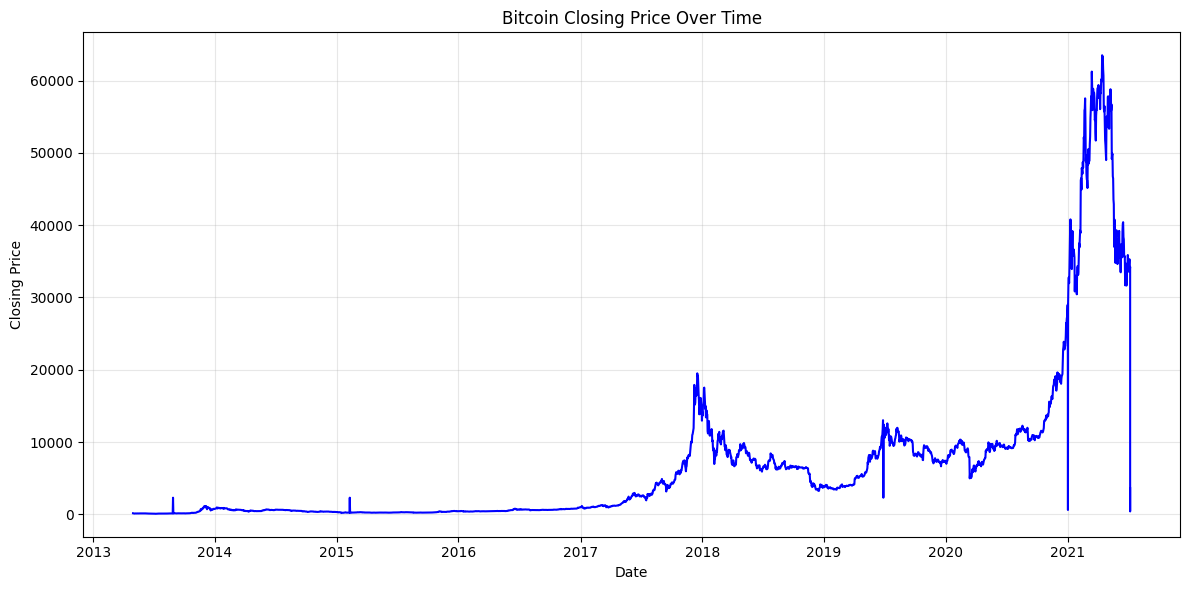

In [57]:
# Plot the Bitcoin closing price over time
plt.figure(figsize=(12, 6))
plt.plot(bitcoin["Date"], bitcoin["Close"], color="blue")

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

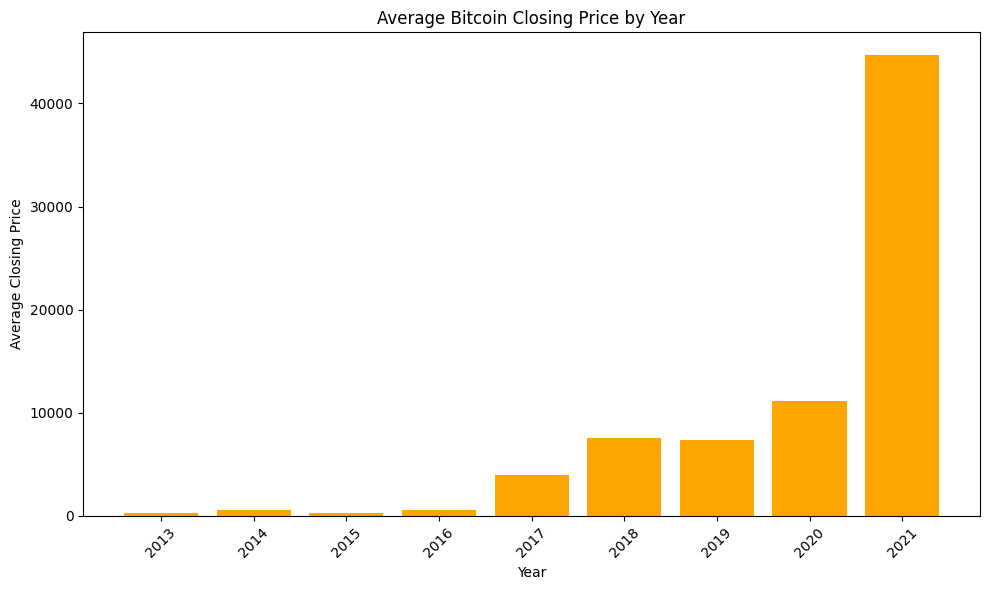

In [58]:
# Plot the average Bitcoin closing price for each year
yearly_close = bitcoin.groupby("Year")["Close"].mean()

plt.figure(figsize=(10, 6))
plt.bar(yearly_close.index, yearly_close.values, color="orange")

plt.title("Average Bitcoin Closing Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.xticks(yearly_close.index, rotation=45)
plt.tight_layout()
plt.show()

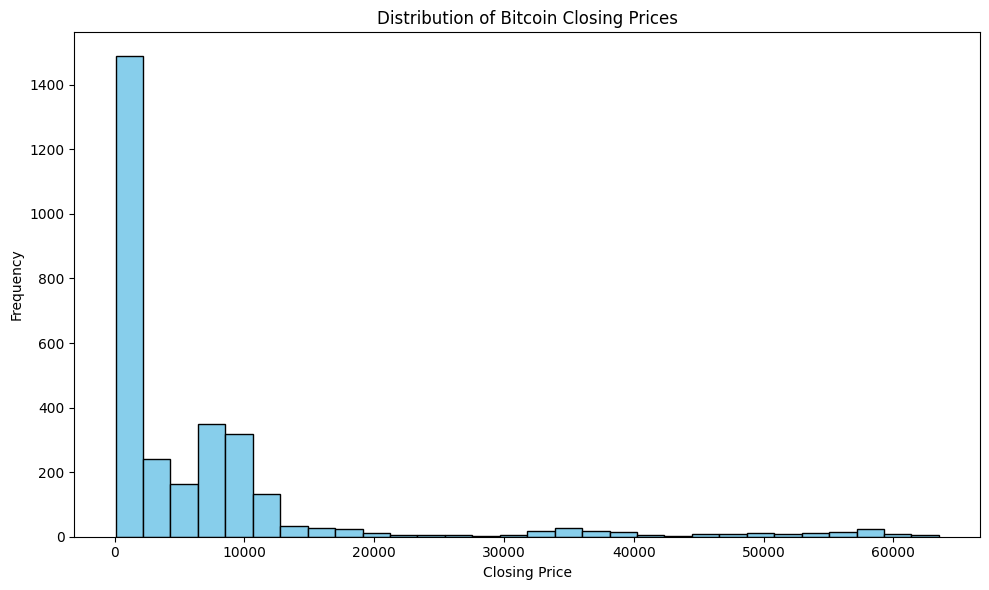

In [59]:
# Display the distribution of Bitcoin closing prices
plt.figure(figsize=(10, 6))
plt.hist(
    bitcoin["Close"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Bitcoin Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

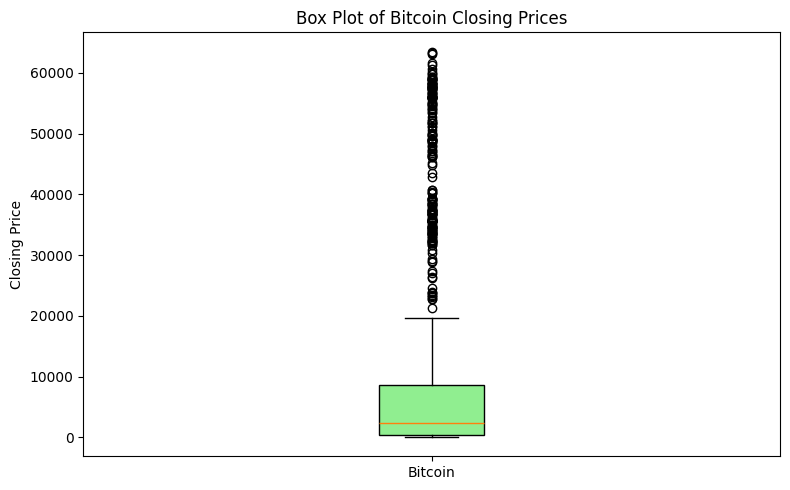

In [60]:
# Display the spread and possible outliers in closing prices
plt.figure(figsize=(8, 5))
plt.boxplot(
    bitcoin["Close"],
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen")
)

plt.title("Box Plot of Bitcoin Closing Prices")
plt.ylabel("Closing Price")
plt.xticks([1], ["Bitcoin"])
plt.tight_layout()
plt.show()

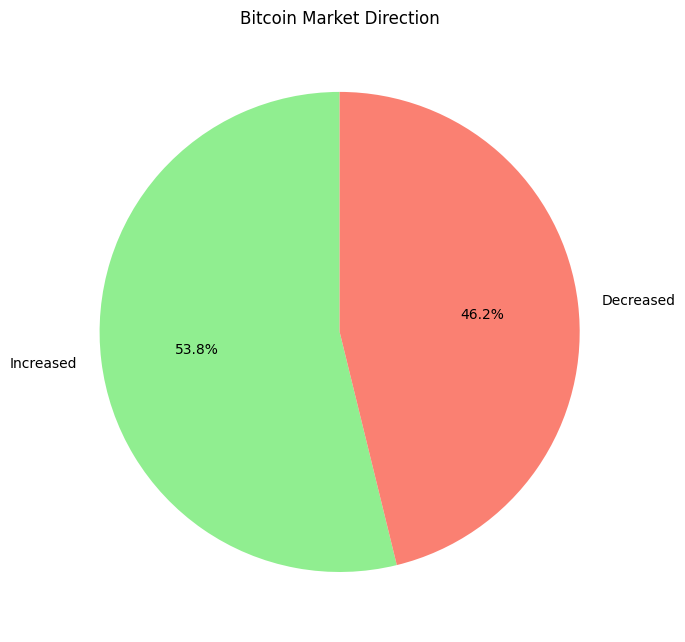

In [61]:
# Display the percentage of increased and decreased market days
direction_count = bitcoin["Market_Direction"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    direction_count.values,
    labels=direction_count.index,
    autopct="%1.1f%%",
    colors=["lightgreen", "salmon"],
    startangle=90
)

plt.title("Bitcoin Market Direction")
plt.tight_layout()
plt.show()

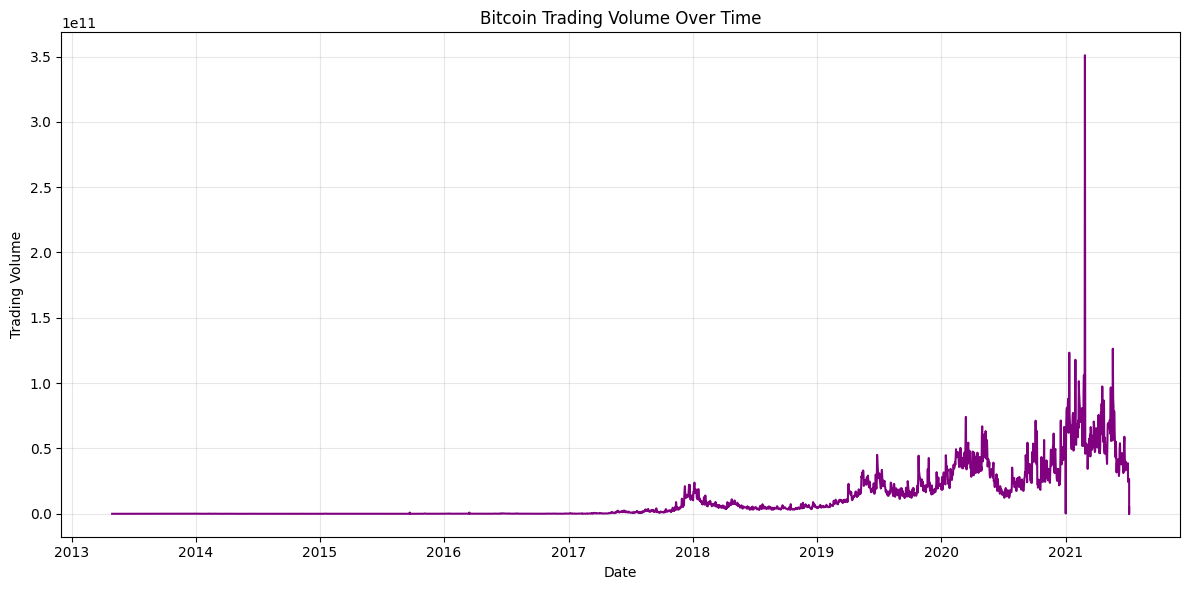

In [62]:
# Plot Bitcoin trading volume over time
plt.figure(figsize=(12, 6))
plt.plot(
    bitcoin["Date"],
    bitcoin["Volume"],
    color="purple"
)

plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

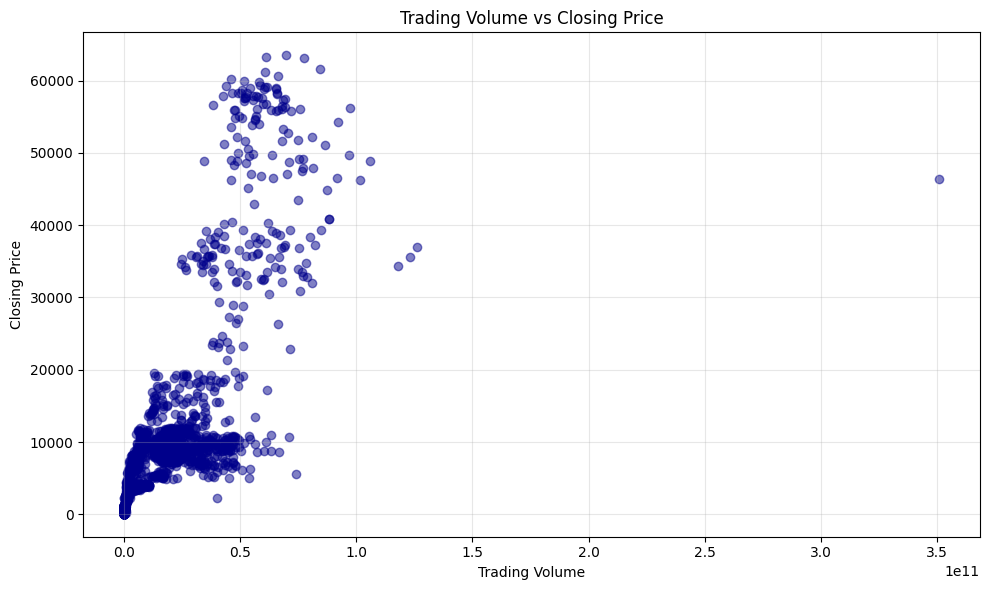

In [63]:
# Display the relationship between trading volume and closing price
plt.figure(figsize=(10, 6))
plt.scatter(
    bitcoin["Volume"],
    bitcoin["Close"],
    color="darkblue",
    alpha=0.5
)

plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

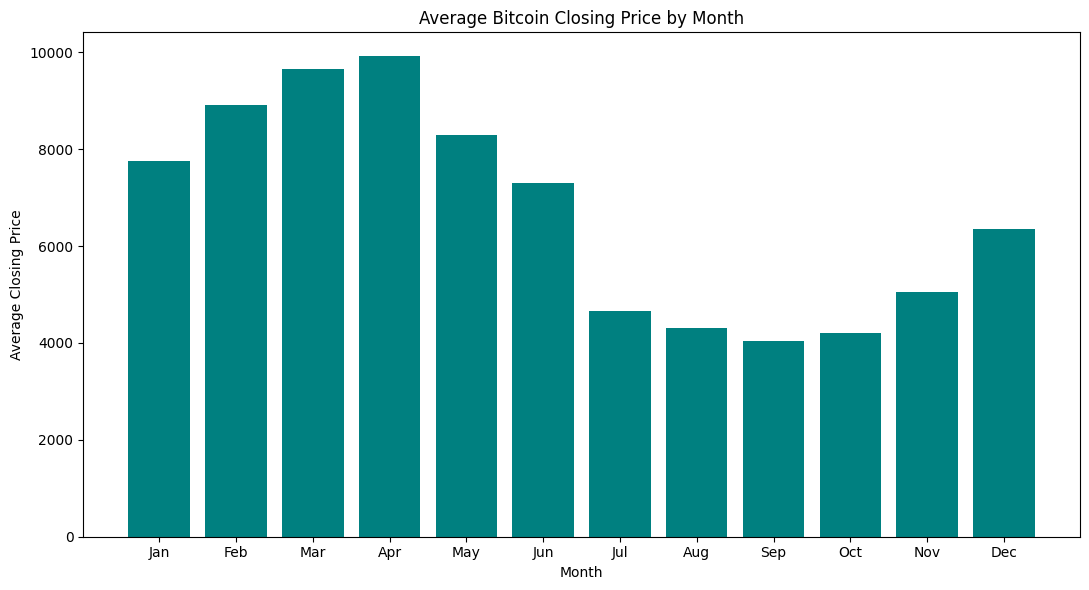

In [64]:
# Plot the average Bitcoin closing price for each month
monthly_close = bitcoin.groupby("Month")["Close"].mean()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(11, 6))
plt.bar(
    month_names,
    monthly_close.reindex(range(1, 13)).values,
    color="teal"
)

plt.title("Average Bitcoin Closing Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.tight_layout()
plt.show()

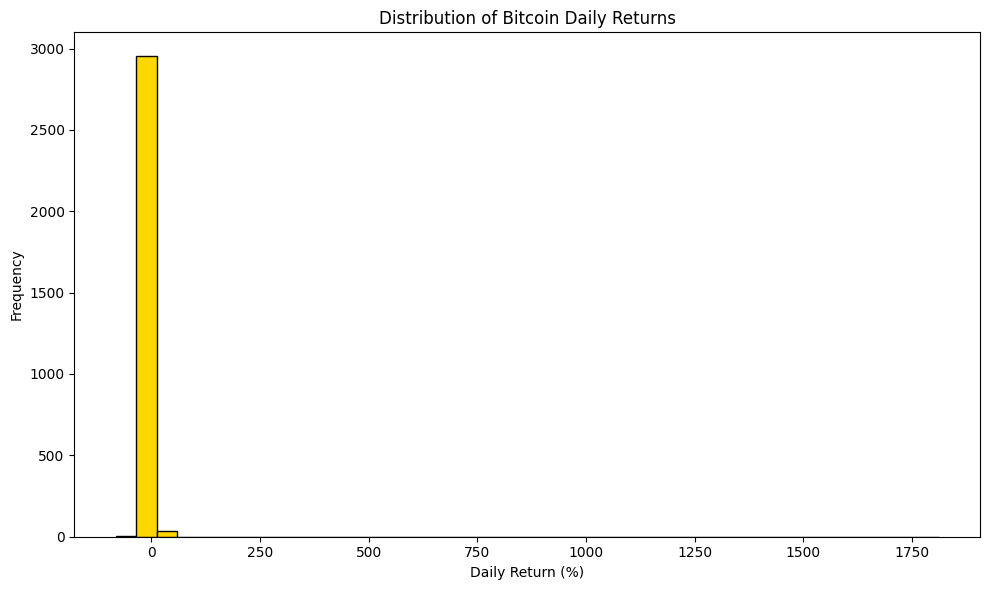

In [65]:
# Display the distribution of daily return percentages
plt.figure(figsize=(10, 6))
plt.hist(
    bitcoin["Daily_Return_Percentage"],
    bins=40,
    color="gold",
    edgecolor="black"
)

plt.title("Distribution of Bitcoin Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

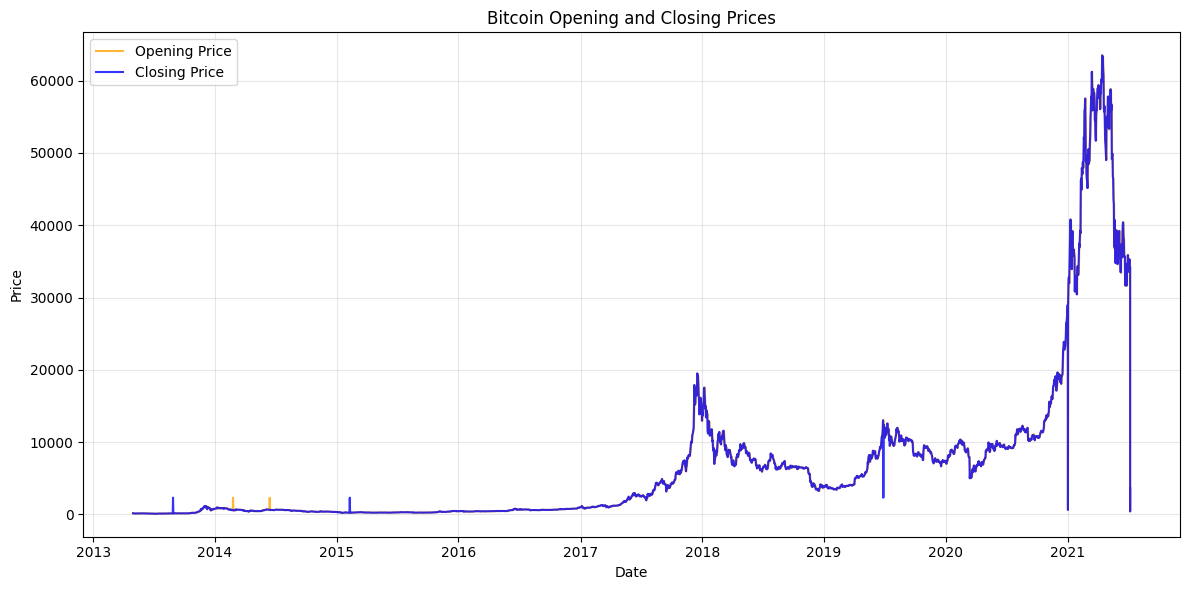

In [66]:
# Compare Bitcoin opening and closing prices over time
plt.figure(figsize=(12, 6))
plt.plot(
    bitcoin["Date"],
    bitcoin["Open"],
    label="Opening Price",
    color="orange",
    alpha=0.8
)
plt.plot(
    bitcoin["Date"],
    bitcoin["Close"],
    label="Closing Price",
    color="blue",
    alpha=0.8
)

plt.title("Bitcoin Opening and Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

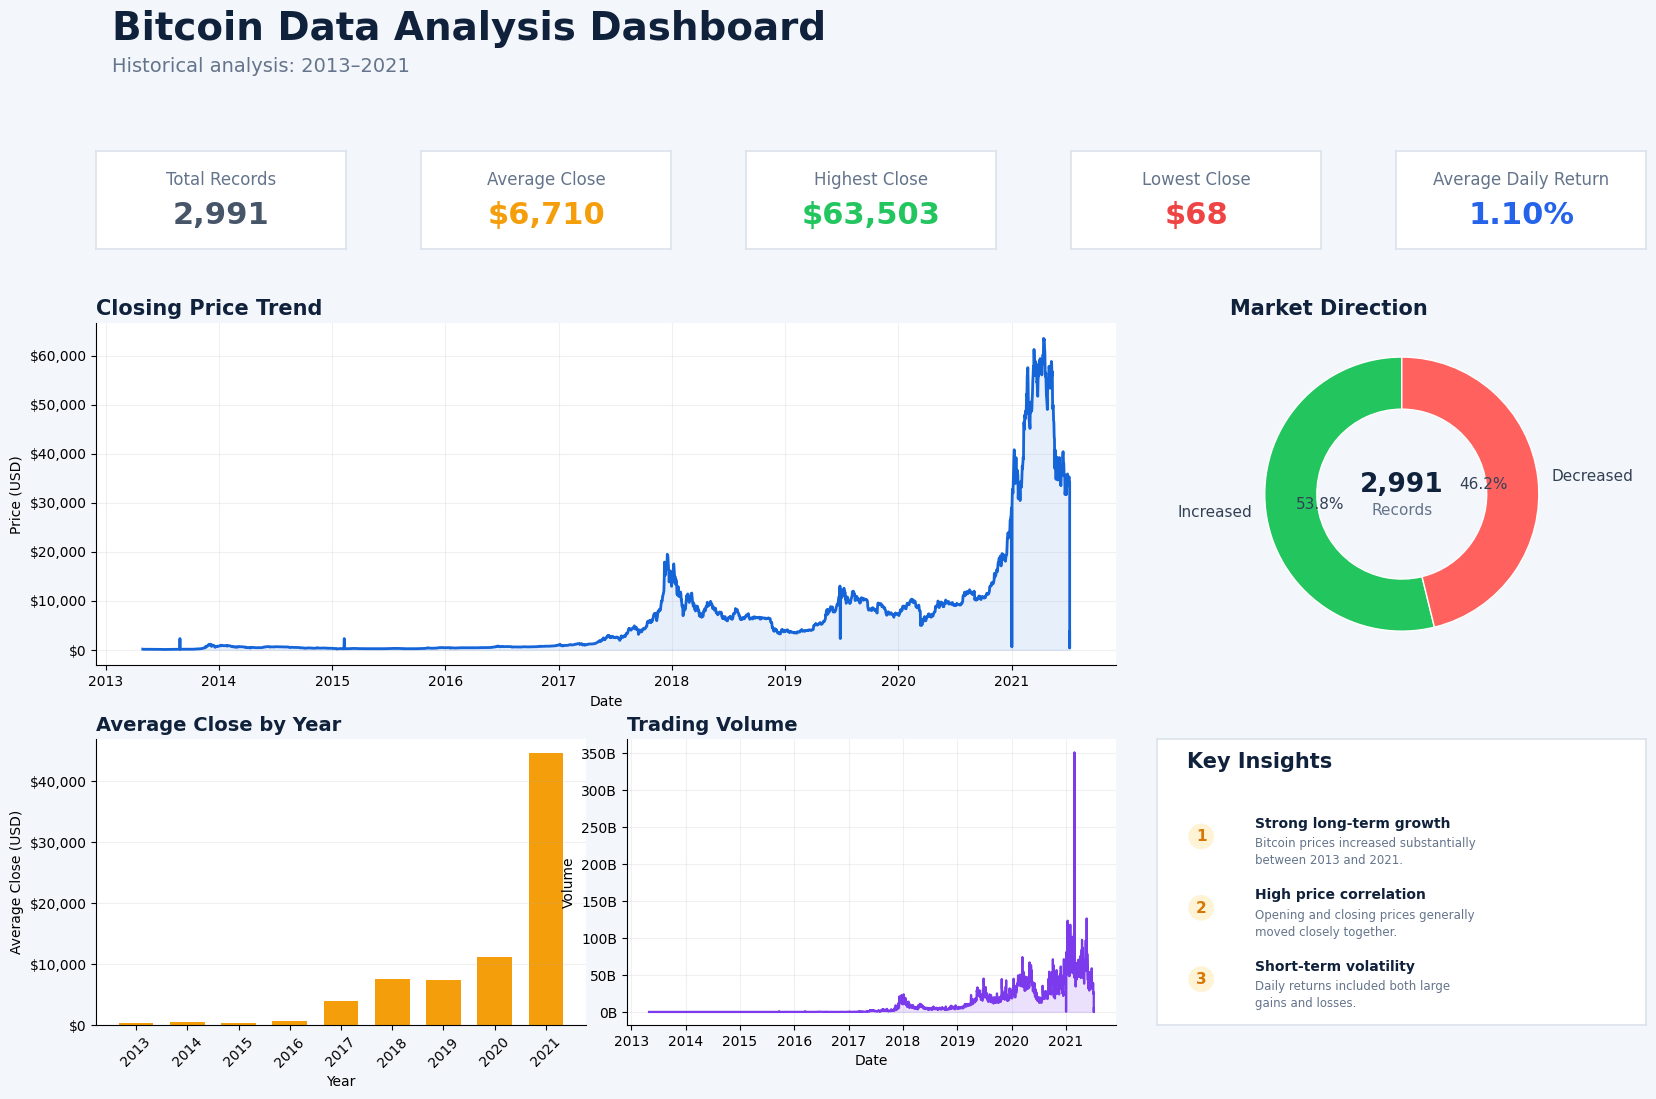

In [68]:
# Create and save the complete Bitcoin data-analysis dashboard
from matplotlib.ticker import FuncFormatter

records = len(bitcoin)
average_close = bitcoin["Close"].mean()
highest_close = bitcoin["Close"].max()
lowest_close = bitcoin["Close"].min()
average_return = bitcoin["Daily_Return_Percentage"].mean()

yearly_close = bitcoin.groupby("Year")["Close"].mean()

direction_count = (
    bitcoin["Market_Direction"]
    .value_counts()
    .reindex(["Increased", "Decreased"])
)

fig = plt.figure(
    figsize=(20, 13),
    facecolor="#F3F6FA"
)

dashboard = fig.add_gridspec(
    4,
    12,
    height_ratios=[0.65, 1.2, 4.2, 3.5],
    hspace=0.38,
    wspace=0.45
)

title_ax = fig.add_subplot(dashboard[0, :])
title_ax.axis("off")

title_ax.text(
    0.01,
    0.70,
    "Bitcoin Data Analysis Dashboard",
    fontsize=28,
    fontweight="bold",
    color="#10213B"
)

title_ax.text(
    0.01,
    0.10,
    "Historical analysis: 2013–2021",
    fontsize=14,
    color="#64748B"
)

kpi_grid = dashboard[1, :].subgridspec(
    1,
    5,
    wspace=0.30
)

kpi_titles = [
    "Total Records",
    "Average Close",
    "Highest Close",
    "Lowest Close",
    "Average Daily Return"
]

kpi_values = [
    f"{records:,}",
    f"${average_close:,.0f}",
    f"${highest_close:,.0f}",
    f"${lowest_close:,.0f}",
    f"{average_return:.2f}%"
]

kpi_colors = [
    "#475569",
    "#F59E0B",
    "#22C55E",
    "#EF4444",
    "#2563EB"
]

for position in range(5):
    kpi_ax = fig.add_subplot(kpi_grid[0, position])
    kpi_ax.set_facecolor("white")
    kpi_ax.set_xticks([])
    kpi_ax.set_yticks([])

    for spine in kpi_ax.spines.values():
        spine.set_color("#DCE3EC")
        spine.set_linewidth(1.2)

    kpi_ax.text(
        0.5,
        0.70,
        kpi_titles[position],
        ha="center",
        va="center",
        fontsize=12,
        color="#64748B",
        transform=kpi_ax.transAxes
    )

    kpi_ax.text(
        0.5,
        0.34,
        kpi_values[position],
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=kpi_colors[position],
        transform=kpi_ax.transAxes
    )

trend_ax = fig.add_subplot(dashboard[2, :8])
trend_ax.set_facecolor("white")

trend_ax.plot(
    bitcoin["Date"],
    bitcoin["Close"],
    color="#1565D8",
    linewidth=2
)

trend_ax.fill_between(
    bitcoin["Date"],
    bitcoin["Close"],
    color="#1565D8",
    alpha=0.10
)

trend_ax.set_title(
    "Closing Price Trend",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#10213B"
)

trend_ax.set_xlabel("Date")
trend_ax.set_ylabel("Price (USD)")
trend_ax.grid(alpha=0.18)

trend_ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

trend_ax.spines[["top", "right"]].set_visible(False)

direction_ax = fig.add_subplot(dashboard[2, 8:])
direction_ax.set_facecolor("white")

direction_ax.set_title(
    "Market Direction",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#10213B"
)

direction_ax.pie(
    direction_count.values,
    labels=direction_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#22C55E", "#FF625E"],
    wedgeprops={
        "width": 0.38,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 11,
        "color": "#334155"
    }
)

direction_ax.text(
    0,
    0.07,
    f"{records:,}",
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold",
    color="#10213B"
)

direction_ax.text(
    0,
    -0.12,
    "Records",
    ha="center",
    va="center",
    fontsize=11,
    color="#64748B"
)

year_ax = fig.add_subplot(dashboard[3, :4])
year_ax.set_facecolor("white")

year_ax.bar(
    yearly_close.index.astype(str),
    yearly_close.values,
    color="#F59E0B",
    width=0.68
)

year_ax.set_title(
    "Average Close by Year",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="#10213B"
)

year_ax.set_xlabel("Year")
year_ax.set_ylabel("Average Close (USD)")
year_ax.tick_params(axis="x", rotation=45)
year_ax.grid(axis="y", alpha=0.18)

year_ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

year_ax.spines[["top", "right"]].set_visible(False)

volume_ax = fig.add_subplot(dashboard[3, 4:8])
volume_ax.set_facecolor("white")

volume_ax.plot(
    bitcoin["Date"],
    bitcoin["Volume"],
    color="#7C3AED",
    linewidth=1.6
)

volume_ax.fill_between(
    bitcoin["Date"],
    bitcoin["Volume"],
    color="#7C3AED",
    alpha=0.15
)

volume_ax.set_title(
    "Trading Volume",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="#10213B"
)

volume_ax.set_xlabel("Date")
volume_ax.set_ylabel("Volume")
volume_ax.grid(alpha=0.18)

volume_ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value / 1e9:.0f}B"
    )
)

volume_ax.spines[["top", "right"]].set_visible(False)

insight_ax = fig.add_subplot(dashboard[3, 8:])
insight_ax.set_facecolor("white")
insight_ax.set_xticks([])
insight_ax.set_yticks([])

for spine in insight_ax.spines.values():
    spine.set_color("#DCE3EC")
    spine.set_linewidth(1.2)

insight_ax.text(
    0.06,
    0.90,
    "Key Insights",
    fontsize=15,
    fontweight="bold",
    color="#10213B",
    transform=insight_ax.transAxes
)

insight_headings = [
    "Strong long-term growth",
    "High price correlation",
    "Short-term volatility"
]

insight_descriptions = [
    "Bitcoin prices increased substantially\nbetween 2013 and 2021.",
    "Opening and closing prices generally\nmoved closely together.",
    "Daily returns included both large\ngains and losses."
]

y_positions = [0.66, 0.41, 0.16]

for number, (heading, description, y_position) in enumerate(
    zip(
        insight_headings,
        insight_descriptions,
        y_positions
    ),
    start=1
):
    insight_ax.text(
        0.09,
        y_position,
        str(number),
        fontsize=11,
        fontweight="bold",
        color="#D97706",
        ha="center",
        va="center",
        bbox={
            "boxstyle": "circle,pad=0.35",
            "facecolor": "#FFF3D6",
            "edgecolor": "none"
        },
        transform=insight_ax.transAxes
    )

    insight_ax.text(
        0.20,
        y_position + 0.045,
        heading,
        fontsize=10,
        fontweight="bold",
        color="#10213B",
        va="center",
        transform=insight_ax.transAxes
    )

    insight_ax.text(
        0.20,
        y_position - 0.055,
        description,
        fontsize=8.5,
        color="#64748B",
        va="center",
        linespacing=1.4,
        transform=insight_ax.transAxes
    )

plt.savefig(
    "bitcoin_dashboard.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()